# import libraries

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# use seaborn plotting defaults
import seaborn as sns; sns.set()

# create dataset 
Create a perfcelty linear data with 2 classes 

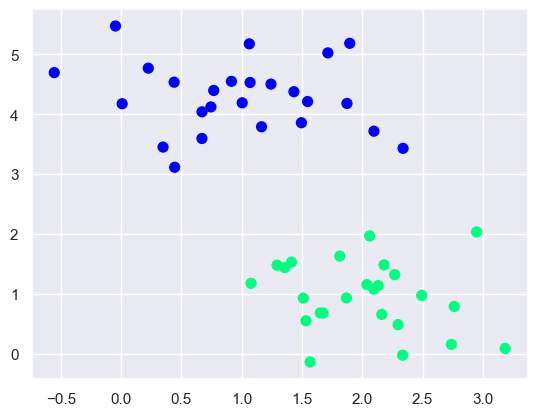

In [4]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=50, centers=2,
                  random_state=0, cluster_std=0.60)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plt.show()

# Hard Margin SVM

In [6]:
from sklearn.svm import SVC # "Support vector classifier"
model = SVC(kernel='linear', C=1)
model.fit(X, y)

SVC(C=1, kernel='linear')

# plot graph

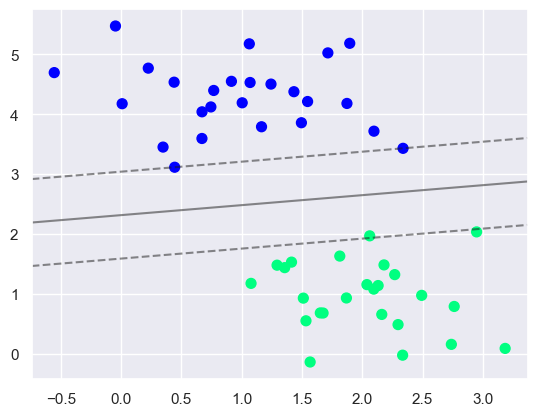

In [7]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision function for a 2D SVC"""
    if ax is None:
        ax = plt.gca()
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    
    # create grid to evaluate model
    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)
    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T
    P = model.decision_function(xy).reshape(X.shape)
    
    # plot decision boundary and margins
    ax.contour(X, Y, P, colors='k',
               levels=[-1, 0, 1], alpha=0.5,
               linestyles=['--', '-', '--'])
    
    # plot support vectors
    if plot_support:
        ax.scatter(model.support_vectors_[:, 0],
                   model.support_vectors_[:, 1],
                   s=300, linewidth=1, facecolors='none');
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    
    
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
plot_svc_decision_function(model)

# Support vectors 

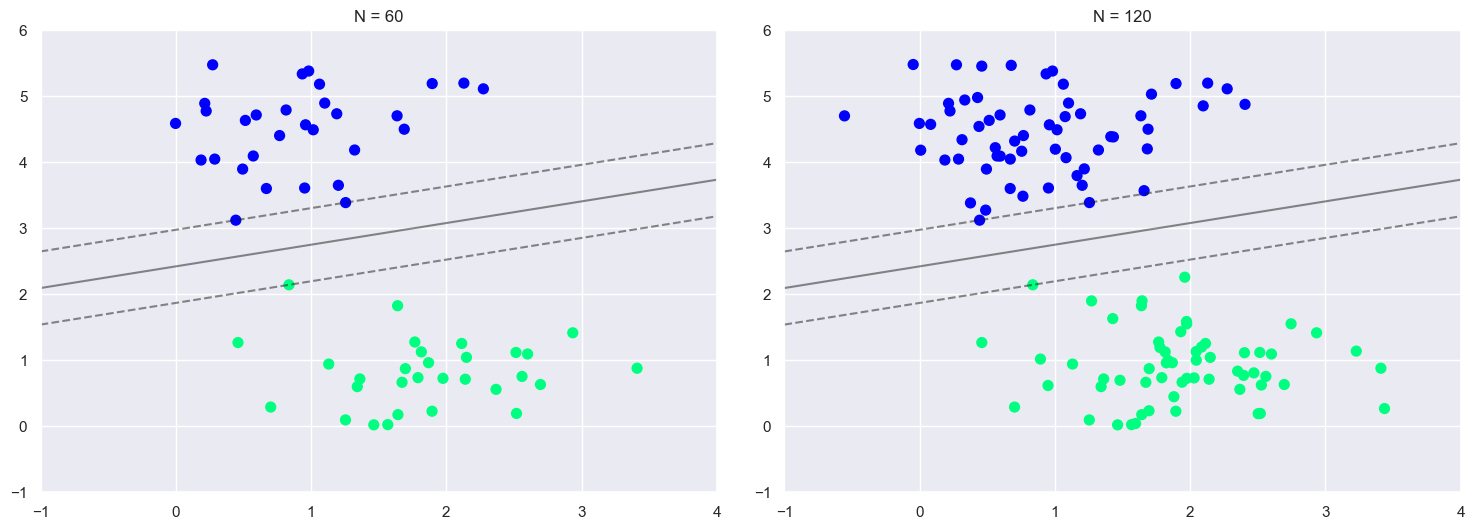

In [8]:
def plot_svm(N=10, ax=None):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)
    
    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)
for axi, N in zip(ax, [60, 120]):
    plot_svm(N, axi)
    axi.set_title('N = {0}'.format(N))

In [14]:
def plot_svm(N=10, ax=0):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)
    
    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

In [ ]:
import ipywidgets as widgets

def plot_svm(N=10, ax=0):
    X, y = make_blobs(n_samples=200, centers=2,
                      random_state=0, cluster_std=0.60)
    X = X[:N]
    y = y[:N]
    model = SVC(kernel='linear', C=1E10)
    model.fit(X, y)
    
    ax = ax or plt.gca()
    ax.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)
    plot_svc_decision_function(model, ax)

widgets.interact ( plot_svm,N=(0,200,10))

interactive(children=(IntSlider(value=10, description='N', max=200, step=10), IntSlider(value=0, description='…

<function __main__.plot_svm(N=10, ax=0)>

In [ ]:
def plot_svc_decision_function(model, ax=None, plot_support=True):
    """Plot the decision boundary and margins of a linear SVM."""
    
    if ax is None:
        ax = plt.gca()

    # Save the current limits before drawing contours
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()

    x = np.linspace(xlim[0], xlim[1], 30)
    y = np.linspace(ylim[0], ylim[1], 30)

    Y, X = np.meshgrid(y, x)
    xy = np.vstack([X.ravel(), Y.ravel()]).T

    P = model.decision_function(xy).reshape(X.shape)

    ax.contour(
        X,
        Y,
        P,
        colors="k",
        levels=[-1, 0, 1],
        alpha=0.5,
        linestyles=["--", "-", "--"]
    )

    if plot_support:
        ax.scatter(
            model.support_vectors_[:, 0],
            model.support_vectors_[:, 1],
            s=300,
            linewidth=1,
            facecolors="none",
            edgecolors="k"
        )

    # Restore the limits so contour does not change them
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)


def plot_svm(N=10, ax=None):
    # Generate the same dataset each time
    X, y = make_blobs(
        n_samples=200,
        centers=2,
        random_state=0,
        cluster_std=0.60
    )

    X = X[:N]
    y = y[:N]

    model = SVC(kernel="linear", C=1E10)
    model.fit(X, y)

    # Use the supplied axes, or create/use the current axes
    if ax is None:
        ax = plt.gca()

    # Clear the previous plot during slider interaction
    ax.clear()

    # Set fixed limits before plotting
    ax.set_xlim(-1, 4)
    ax.set_ylim(-1, 6)

    ax.scatter(
        X[:, 0],
        X[:, 1],
        c=y,
        s=50,
        cmap="winter"
    )

    plot_svc_decision_function(model, ax=ax)

    ax.set_title(f"SVM using {N} observations")
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")


widgets.interact(
    plot_svm,
    N=widgets.IntSlider(
        value=10,
        min=10,
        max=200,
        step=10,
        description="N:"
    ),
    ax=widgets.fixed(None)
)

interactive(children=(IntSlider(value=10, description='N:', max=200, min=10, step=10), Output()), _dom_classes…

<function __main__.plot_svm(N=10, ax=None)>

if you use correctly svm it protect you from outleirs 

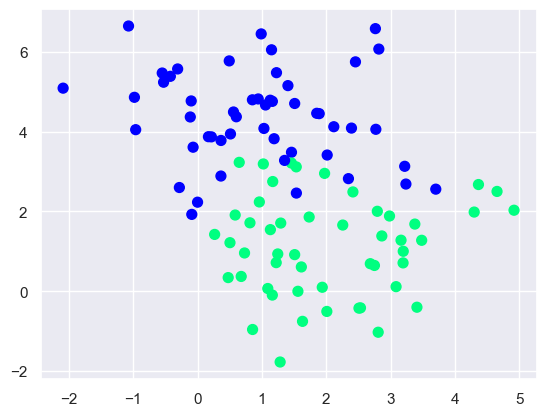

In [21]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=1.2)
plt.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter');

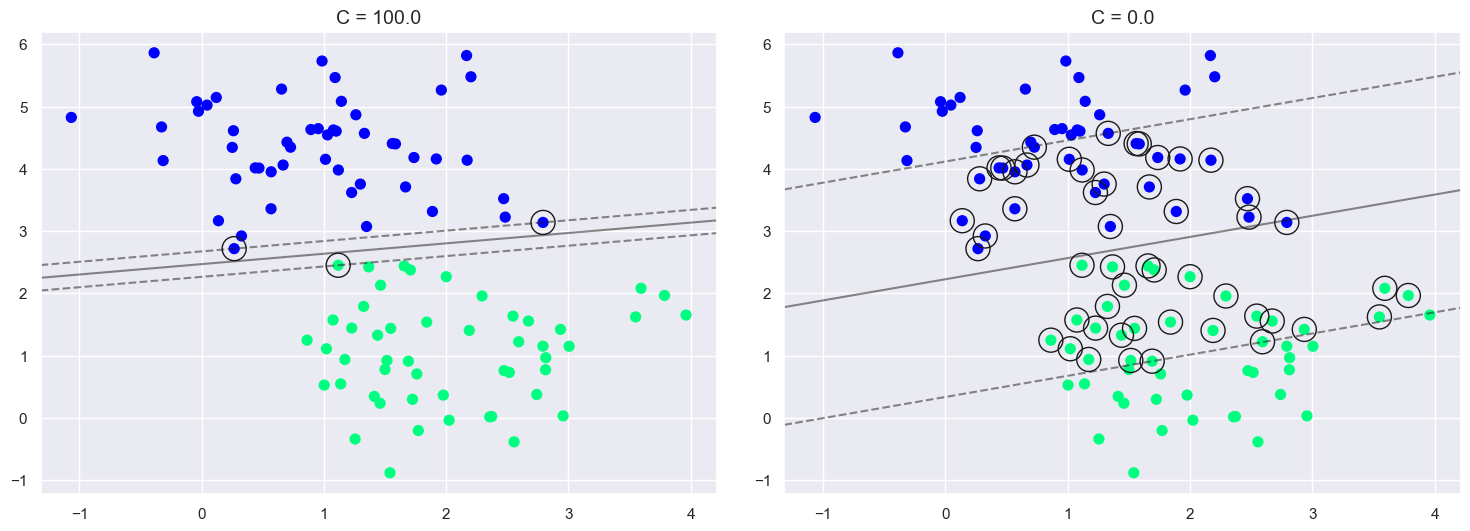

In [22]:
X, y = make_blobs(n_samples=100, centers=2,
                  random_state=0, cluster_std=0.8)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))
fig.subplots_adjust(left=0.0625, right=0.95, wspace=0.1)

for axi, C in zip(ax, [100.0, 0.01]):
    model = SVC(kernel='linear', C=C).fit(X, y)
    axi.scatter(X[:, 0], X[:, 1], c=y, s=50, cmap='winter')
    plot_svc_decision_function(model, axi)
    axi.scatter(model.support_vectors_[:, 0],
                model.support_vectors_[:, 1],
                s=300, lw=1, facecolors='none');
    axi.set_title('C = {0:.1f}'.format(C), size=14)